### Fine-tuning geneformer for cell type classification 

This tutorial covers end-to-end fine-tuning of a single-cell foundation model in DECONVersation using Geneformer. It walks through preparing an annotated single-cell reference, tokenizing it for the model, building class-balanced train, evaluation, and held-out test splits, and fine-tuning a pretrained Geneformer model for cell type classification. Performance is assessed on the held-out test set using accuracy and macro F1. While this tutorial uses Geneformer, the workflow applies to the other foundation models supported by DECONVersation.

#### Import libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'

In [6]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
import anndata as ad
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation, models, pseudobulk

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.
geneformer successfully imported.
Cell2Sentence is not installed. Skipping related functions.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 1: Load single cell dataset

Here we load the single-cell data. Geneformer requires Ensembl IDs, so we ensure that `adata.var.index` holds Ensembl IDs rather than gene symbols. We then run `preprocessing.load_and_prep_data()` to prepare the object for Geneformer fine-tuning.

In [8]:
# Path to h5ad data
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmcNuc/10xpbmcNuc_symbol.h5ad"
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

In [9]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Remove unmapped genes
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = preprocessing.load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

In [10]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Remove unmapped genes
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref.var.index = adata_ref.var["gene_id"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
adata_ref = preprocessing.load_and_prep_data(adata = adata_ref, cell_type_col= "broad_type", mode="geneformer")

In [9]:
#adata_ref.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest_hao/hao_data_finetuning.h5ad")

#### Step 2: Fine-tune geneformer 
Here we fine-tune Geneformer on the reference dataset for cell type prediction. We pass an output directory in which to store the saved model, and set `tokenize=True` to tokenize the dataset; if tokenized data already exists, set this to `False` and pass its path to `tokenized_data_dir`. We set `undersample=True` to fine-tune on a subset of the reference, with `n_per_class=200` capping the training pool at 200 cells per cell type, 20% of which is held out for evaluation. A separate test set of up to `n_test_per_class=10` cells per cell type is drawn from cells not included in the training pool.

In [32]:
gf_finetuned_metrics = models.train_geneformer_cell_classifier(
    adata_ref,
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest_hao/",
    state_key = "broad_type",
    tokenize = True,
    token_output_prefix = "tokenized", 
    undersample = True,
    n_per_class = 200,
    n_test_per_class = 10,
    eval_fraction = 0.2,
    model_directory = "ctheodoris/Geneformer",
    training_args = {"num_train_epochs": 3},
    output_prefix = "gf_finetune",
    metrics_output_dir = None
)

#### Explore training metrics

Here we visualize the confusion matrix for the evaluation set computed during fine-tuning, showing classification performance across cell types.

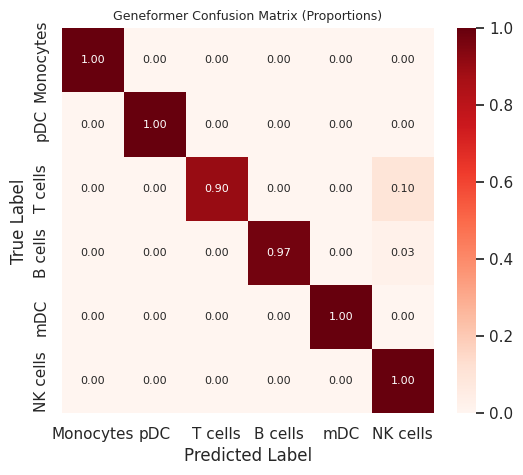

In [33]:
# Get confusion matrix 
conf_matrix = gf_finetuned_metrics["train_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                 
    fmt=".2f",                  
    cmap="Reds",             
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

#### Explore testing metrics

Here we visualize the confusion matrix for the test set computed during fine-tuning, showing classification performance across cell types.

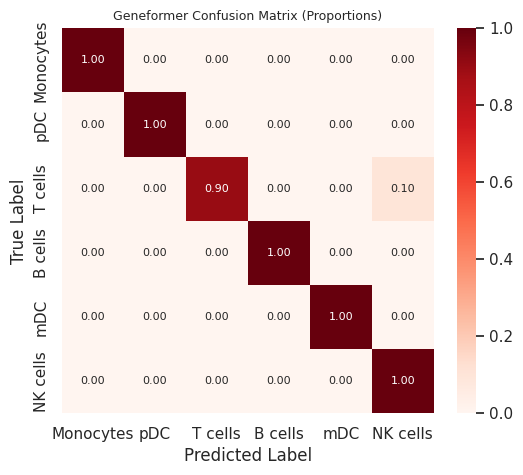

In [34]:
# Get confusion matrix 
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                 
    fmt=".2f",                  
    cmap="Reds",             
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

#### Compare zeroshot and fine-tuned models

Next, we use `pseudobulk.generate_pseudobulk()` to generate pseudobulk data and `preprocessing.create_signature_matrix()` to create a signature matrix from the reference single-cell data.

In [11]:
# Create pseudobulk
pseudo_bulk, cell_prop = pseudobulk.generate_pseudobulk(adata = adata,   
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 150,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

# Signature matrix
sig_mat = preprocessing.create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

sig_mat = sig_mat.T

#### Extract embeddings (zeroshot)

We now extract Geneformer embeddings from both the pseudobulk data and the signature matrix, using the zero-shot and fine-tuned models in turn. In this cell we use the zero-shot model by passing `model_path="ctheodoris/Geneformer"`. For the fine-tuned model, we pass the path to the model saved during fine-tuning.

In [17]:
# Signature matrix
sig_mat_embed_zs = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

# Pseudobulk
pseudo_bulk_embed_zs = embeddings.extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

#### Extract embeddings (fine-tuned)

In [18]:
# Signature matrix
sig_mat_gf_embed_ft = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest_hao/260921_geneformer_cellClassifier_gf_finetune/ksplit1/",
    layer_to_quant = 18,
    delete_temp_files = True
)

# Pseudobulk
pseudo_bulk_embed_ft = embeddings.extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest_hao/260921_geneformer_cellClassifier_gf_finetune/ksplit1/",
    layer_to_quant = 18,
    delete_temp_files = True
)

#### Run Deconvolution

After extracting embeddings, we run deconvolution with deconvolution.run_deconv(), which uses NNLS as the default solver. We run it on both the zero-shot and fine-tuned embeddings.

In [19]:
# Run deconvolution
result_zs = deconvolution.run_deconv(bulk_df = pseudo_bulk_embed_zs.T, 
                                     signature_df = sig_mat_embed_zs.T)

# Run deconvolution
result_ft = deconvolution.run_deconv(bulk_df = pseudo_bulk_embed_ft.T, 
                                     signature_df = sig_mat_gf_embed_ft.T)

#### Evaluation

Here we compare zeroshot and finetuned results across the 4 different cell types. 

In [20]:
zs_metrics = pd.DataFrame(evaluation.compute_rmse(true_df = cell_prop,
                       pred_df = result_zs, return_per_celltype=True))

In [21]:
ft_metrics = pd.DataFrame(evaluation.compute_rmse(true_df = cell_prop,
                       pred_df = result_ft, return_per_celltype=True))

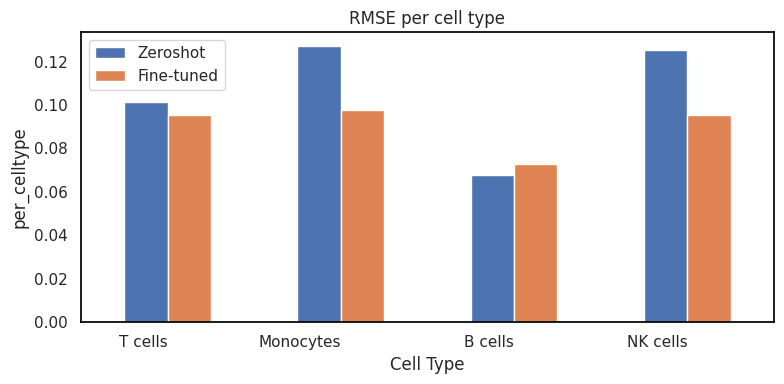

In [29]:
# Combine 'per_celltype' from both dataframes into a single DataFrame
combined_df = pd.DataFrame({
    'Zeroshot': zs_metrics['per_celltype'],
    'Fine-tuned': ft_metrics['per_celltype']
})

# Plot grouped bar plot
combined_df.plot(kind='bar', figsize=(8, 4))
plt.title('RMSE per cell type')
plt.xlabel('Cell Type')
plt.ylabel('per_celltype')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

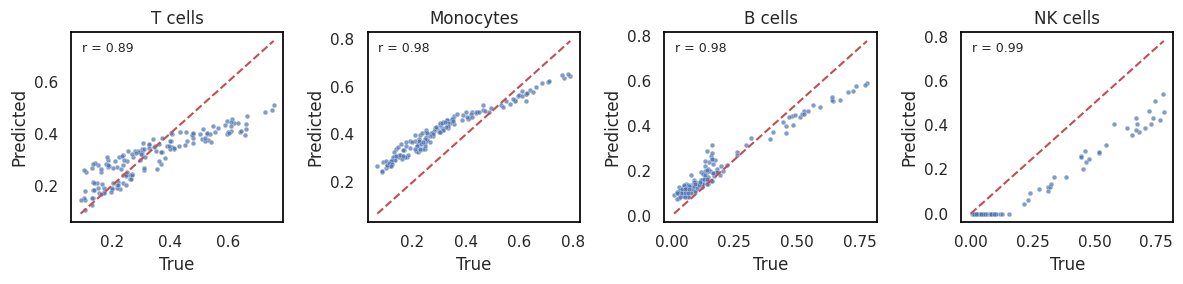

In [52]:
visualization.plot_true_vs_predicted(y_true_df=cell_prop, 
                                     y_pred_df=result_zs, 
                                     stratify_by_celltype=True, n_cols=4)

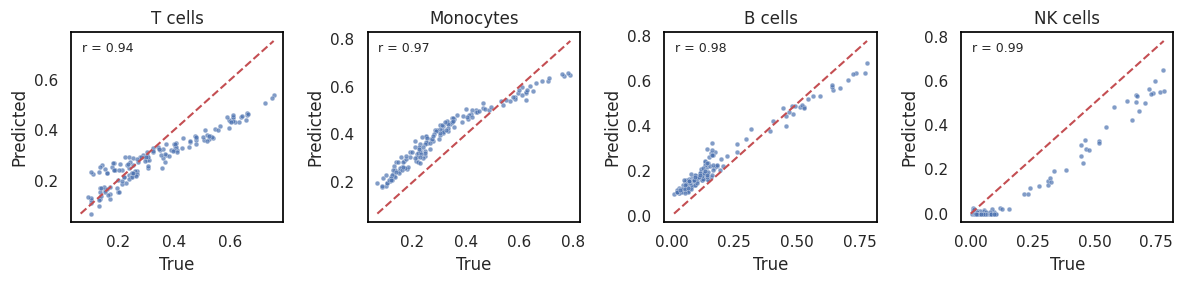

In [53]:
visualization.plot_true_vs_predicted(y_true_df=cell_prop, 
                                     y_pred_df=result_ft, 
                                     stratify_by_celltype=True, n_cols=4)